In [1]:
!pip install onedrivedownloader
from onedrivedownloader import download
import skimage.io as io
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import disk, opening, closing, remove_small_objects
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np

# Justificación: skimage para procesamiento (visto en clase), matplotlib para visualización, numpy para arrays.

# Segunda Imagen

In [2]:
path_file_2 = 'https://universidadfv-my.sharepoint.com/:i:/g/personal/alberto_desantos_ufv_es/EVq7WDpsmUdNpimem9qtc-0Btj8E9McUzg9IccKZN2f-rg?e=tNV0Dz'
download(url = path_file_2, filename = 'Imagen 2.jpg', unzip=False, force_download=True, clean=False)

100%|██████████| 336k/336k [00:00<00:00, 1.24MiB/s]


'Imagen 2.jpg'

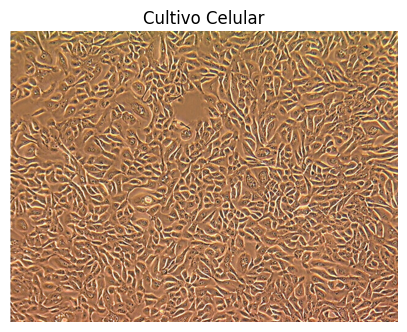

In [3]:
img2 = io.imread("/content/Imagen 2.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(img2)
plt.title('Cultivo Celular')
plt.axis('off')
plt.show()

## Preprocesamiento de la imagen
Pasamos a escala de grises dejando la imagen compuesta por una sola matriz y aplicamos filtro Gaussiano, de manera, que al eliminar ruido de alta frecuencia, estamos suavizando las transiciones para que así el método de segmentación no se confunda con pequeñas irregularidades. También aumentamos el contraste para distinguir mejor el fondo de las células.

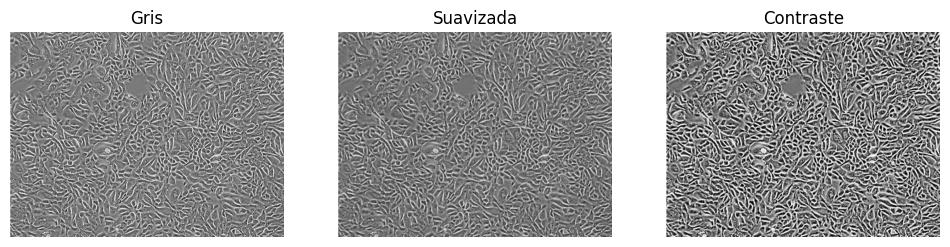

In [4]:
from skimage import color, filters, exposure  # Conversión a gris, filtros y mejora de contraste
import matplotlib.pyplot as plt              # Visualización

img2_gray = color.rgb2gray(img2)             # Pasar la imagen original a escala de grises [0-1]
img2_smooth = filters.gaussian(img2_gray, sigma=1)  # Suavizar para reducir ruido sin borrar forma celular. Sigma = 1 realiza un suavizado moderado, eliminando ruido de alta frecuencia y manteniendo la forma celular
img2_eq = exposure.equalize_adapthist(img2_smooth)  # Mejorar contraste local para separar célula/fondo

plt.figure(figsize=(12,4))                   # Crear lienzo ancho para comparar etapas
plt.subplot(1,3,1); plt.imshow(img2_gray, cmap='gray'); plt.title('Gris'); plt.axis('off')        # Gris
plt.subplot(1,3,2); plt.imshow(img2_smooth, cmap='gray'); plt.title('Suavizada'); plt.axis('off') # Suavizada
plt.subplot(1,3,3); plt.imshow(img2_eq, cmap='gray'); plt.title('Contraste'); plt.axis('off')     # Contraste mejorado
plt.show()


## Aplicamos método de umbralización
Después del preprocesamiento de la imagen, aplicamos el método de Otsu, que nos permite crear automáticamente un umbral entre píxeles oscuros (fondo) y píxeles claros (contorno celular). Es un método que crea un umbral de manera que se minimiza la varianza dentro de cada grupo y maximiza la separación entre ambos.

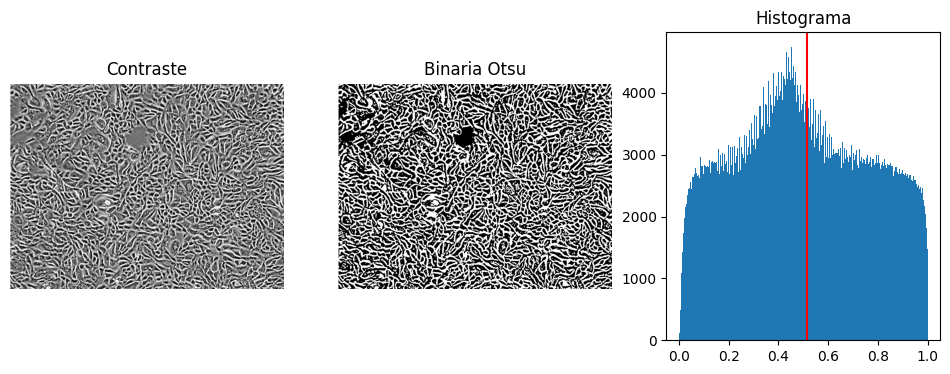

Valor del umbral hallado por Otsu:  0.513671875


In [5]:
th = filters.threshold_otsu(img2_eq)         # Umbral global óptimo según Otsu
binary_otsu = img2_eq > th                   # Máscara binaria: True = célula (intensa), False = fondo

plt.figure(figsize=(12,4))                   # Mostrar etapas clave
plt.subplot(1,3,1); plt.imshow(img2_eq, cmap='gray'); plt.title('Contraste'); plt.axis('off')     # Imagen mejorada
plt.subplot(1,3,2); plt.imshow(binary_otsu, cmap='gray'); plt.title('Binaria Otsu'); plt.axis('off')  # Segmentación
plt.subplot(1,3,3); plt.hist(img2_eq.ravel(), bins=256); plt.axvline(th, c='r'); plt.title('Histograma')  # Histograma+umbral
plt.show()
print("Valor del umbral hallado por Otsu: ",th)

## Posprocesamiento y conteo celular

Antes de contar el número de células es necesario realizar ciertas operaciones de posprocesamiento, pues el método para contar, "labels", asigna un número distinto para cada grupo de píxeles unido, por lo que hay que asegurarse de que lo que se corresponde a las membranas celulares estén bien conectadas para que así el método pueda contar los núcleos. Para ello realizamos una clausura (dilatación + erosión) de manera que se cierren esos pequeños huecos que impidan la unión entre grupos.

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

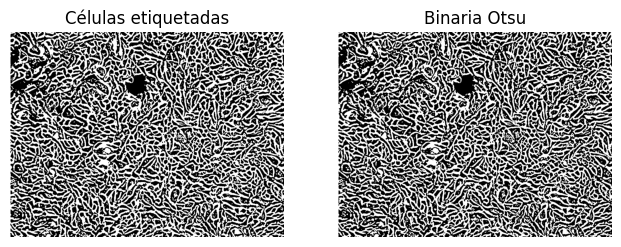

In [6]:
from skimage import morphology, measure  # Morfología y medición
import matplotlib.pyplot as plt

mask = morphology.binary_closing(binary_otsu, morphology.disk(1))      # Suavizar bordes y eliminar ruido fino

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask, cmap='gray'); plt.title('Células etiquetadas'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(binary_otsu, cmap='gray'); plt.title('Binaria Otsu'); plt.axis('off')

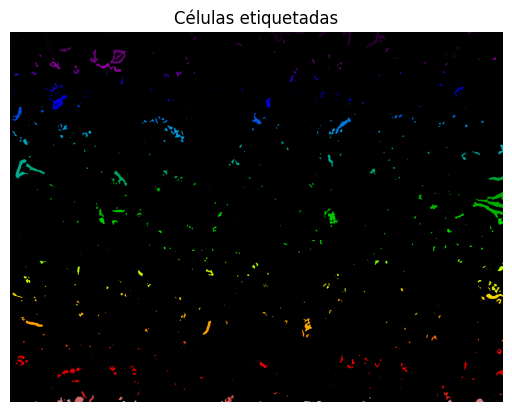

Número de células:  623


In [7]:
labels = measure.label(mask)                                      # Etiquetar regiones conectadas
count = len(measure.regionprops(labels))                          # Contar regiones (células)print(f"Número estimado de células: {count}")                     # Mostrar conteo

plt.imshow(labels, cmap='nipy_spectral'); plt.axis('off'); plt.title('Células etiquetadas'); plt.show()
print("Número de células: ", count)